In [ ]:
import pandas as pd

# Load the dataset
file_path = './data_india_ENRG.xlsx'
data = pd.read_excel(file_path, sheet_name='Sheet1')

data['Combined Date'] = data['Year'].astype(str) + " " + data['Date']
data['Formatted Date'] = pd.to_datetime(data['Combined Date'], format='%Y %d-%b %I%p')

data['Datetime'] = data['Formatted Date'].dt.strftime('%d-%m-%Y %H:%M')

filtered_data = data[['Datetime', 'NA_MW']]

output_file_path = 'data_india_ENRG-2.xlsx'
filtered_data.to_excel(output_file_path, index=False)

print(f"Filtered file saved as: {output_file_path}")


Filtered file saved as: data_india_ENRG-2.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()

In [ ]:
pip install xgboost

In [ ]:
import xgboost as xgb

In [ ]:
file_path = './data_india_ENRG-2.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

In [ ]:
df.tail()

,Datetime,NA_MW
64243,30-04-2024 19:00,201094.24
64244,30-04-2024 20:00,196577.71
64245,30-04-2024 21:00,194782.12
64246,30-04-2024 22:00,194967.39
64247,30-04-2024 23:00,194194.45


In [ ]:
df = df.set_index('Datetime')

In [ ]:
df.head()

,NA_MW
Datetime,
01-01-2017 00:00,108985.17
01-01-2017 01:00,105856.08
01-01-2017 02:00,103115.75
01-01-2017 03:00,102407.04
01-01-2017 04:00,104235.34


In [ ]:
df.index = pd.to_datetime(df.index)

In [ ]:
df

,NA_MW
Datetime,
2017-01-01 00:00:00,108985.17
2017-01-01 01:00:00,105856.08
2017-01-01 02:00:00,103115.75
2017-01-01 03:00:00,102407.04
2017-01-01 04:00:00,104235.34
...,...
2024-04-30 19:00:00,201094.24
2024-04-30 20:00:00,196577.71
2024-04-30 21:00:00,194782.12


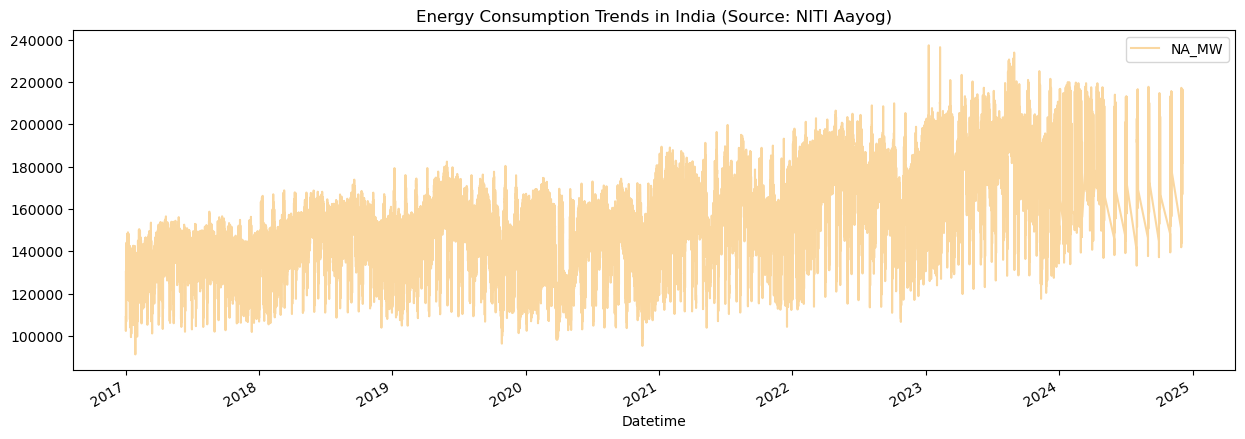

In [ ]:
df.plot(
    style='-',
    figsize=(15, 5),
    color='#FAD7A0',
    title='Energy Consumption Trends in India (Source: NITI Aayog)'
)
plt.show()

In [ ]:
df.index

DatetimeIndex(['2017-01-01 00:00:00', '2017-01-01 01:00:00',
               '2017-01-01 02:00:00', '2017-01-01 03:00:00',
               '2017-01-01 04:00:00', '2017-01-01 05:00:00',
               '2017-01-01 06:00:00', '2017-01-01 07:00:00',
               '2017-01-01 08:00:00', '2017-01-01 09:00:00',
               ...
               '2024-04-30 14:00:00', '2024-04-30 15:00:00',
               '2024-04-30 16:00:00', '2024-04-30 17:00:00',
               '2024-04-30 18:00:00', '2024-04-30 19:00:00',
               '2024-04-30 20:00:00', '2024-04-30 21:00:00',
               '2024-04-30 22:00:00', '2024-04-30 23:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=64248, freq=None)

<Axes: ylabel='Frequency'>

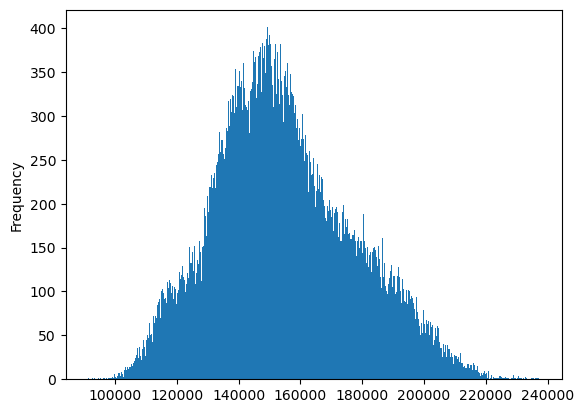

In [ ]:
df['NA_MW'].plot(kind='hist', bins=500)

<Axes: title={'center': 'Outliers'}, xlabel='Datetime'>

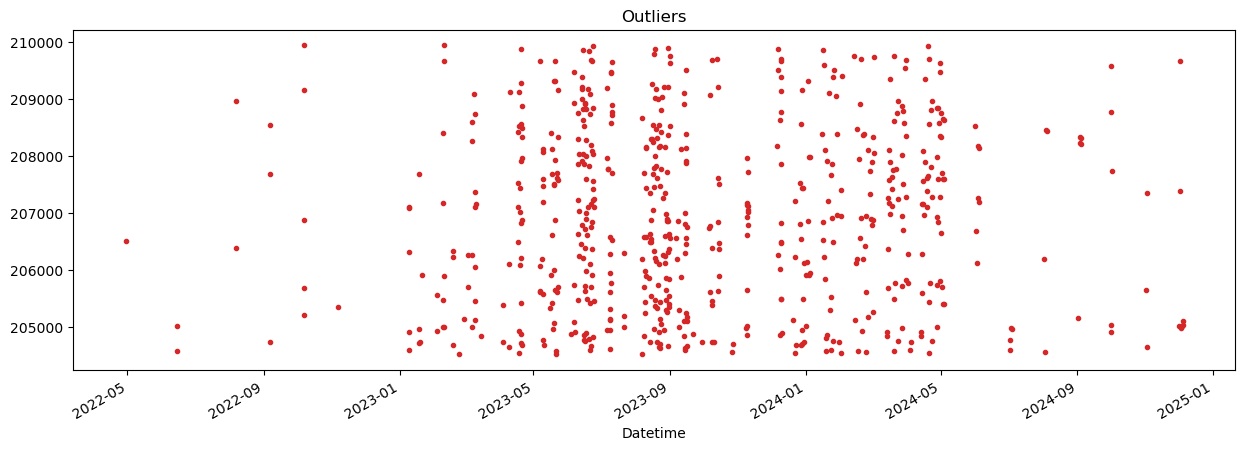

In [ ]:
df.query('NA_MW > NA_MW.quantile(0.99)')['NA_MW'].plot(style='.',figsize=(15, 5), color=color_pal[3], title='Outliers')

In [ ]:
# For handling outliers (e.g., removing extreme values)
df = df[df['NA_MW'] < df['NA_MW'].quantile(0.99)]  # Remove top 1% of values
df = df.query('NA_MW > 100000')

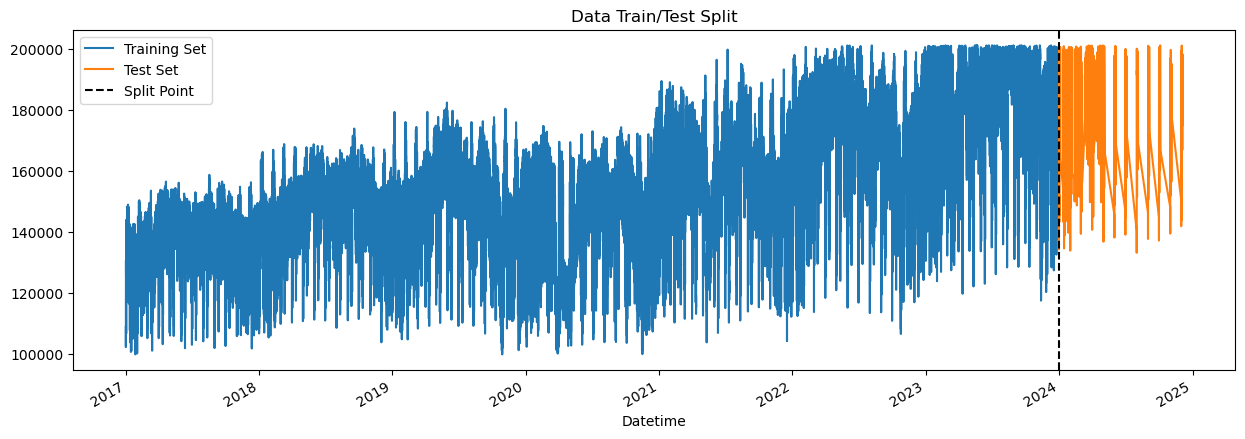

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

cutoff_date = pd.to_datetime('2024-01-01')

train = df.loc[df.index < cutoff_date]
test = df.loc[df.index >= cutoff_date]

fig, ax = plt.subplots(figsize=(15, 5))
train['NA_MW'].plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test['NA_MW'].plot(ax=ax, label='Test Set')
ax.axvline(cutoff_date, color='black', linestyle='--', label='Split Point')
ax.legend(['Training Set', 'Test Set', 'Split Point'])
plt.show()

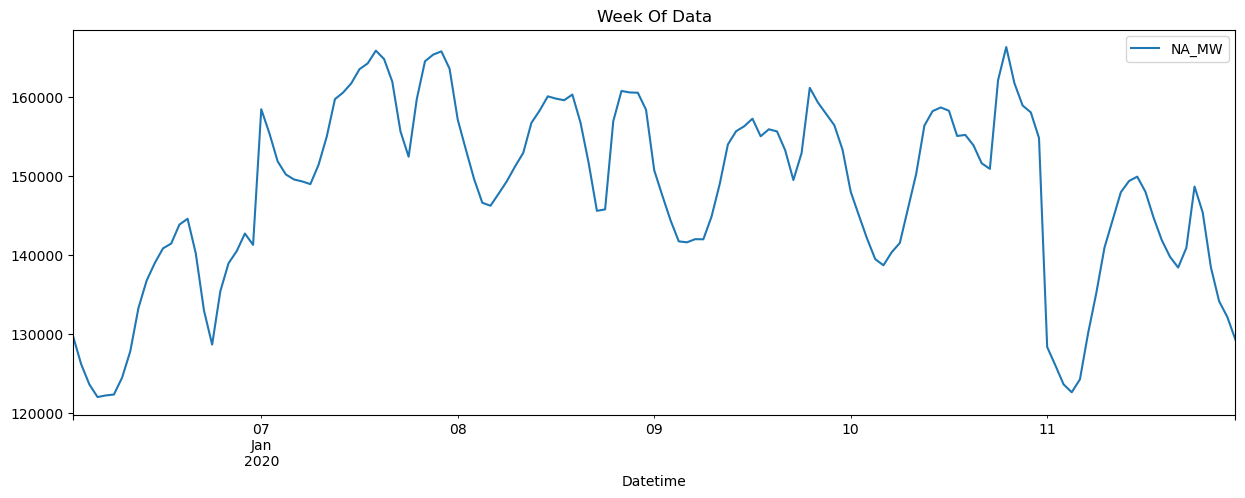

In [ ]:
df.loc[(df.index > '01-06-2020') & (df.index < '01-12-2020')] \
    .plot(figsize=(15, 5), title='Week Of Data')
plt.show()

In [ ]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

In [ ]:
df

,NA_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Datetime,,,,,,,,,
2017-01-01 00:00:00,108985.17,0,6,1,1,2017,1,1,52
2017-01-01 01:00:00,105856.08,1,6,1,1,2017,1,1,52
2017-01-01 02:00:00,103115.75,2,6,1,1,2017,1,1,52
2017-01-01 03:00:00,102407.04,3,6,1,1,2017,1,1,52
2017-01-01 04:00:00,104235.34,4,6,1,1,2017,1,1,52
...,...,...,...,...,...,...,...,...,...
2024-04-30 19:00:00,201094.24,19,1,2,4,2024,121,30,18
2024-04-30 20:00:00,196577.71,20,1,2,4,2024,121,30,18
2024-04-30 21:00:00,194782.12,21,1,2,4,2024,121,30,18


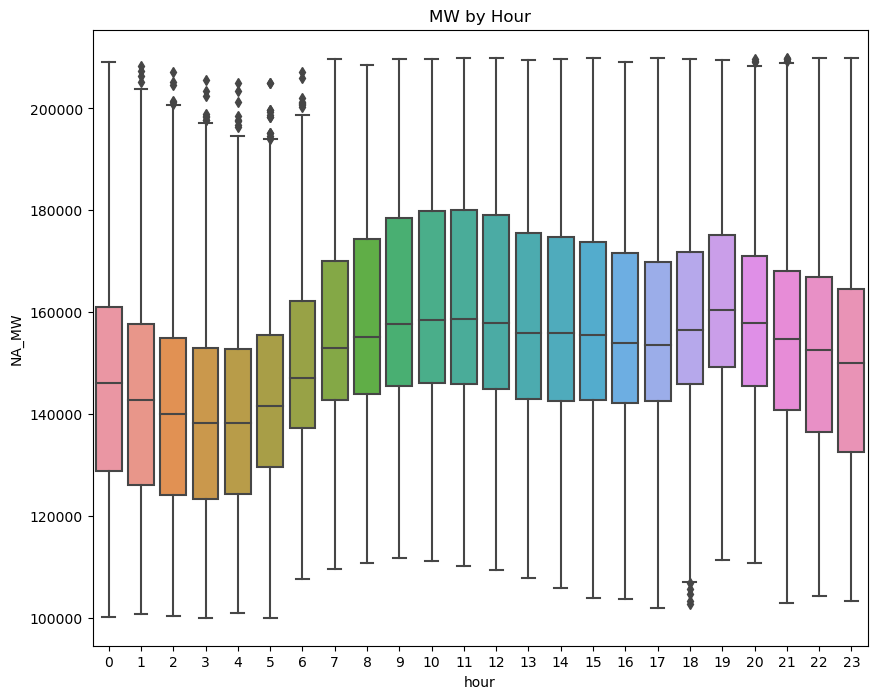

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='hour', y='NA_MW')
ax.set_title('MW by Hour')
plt.show()

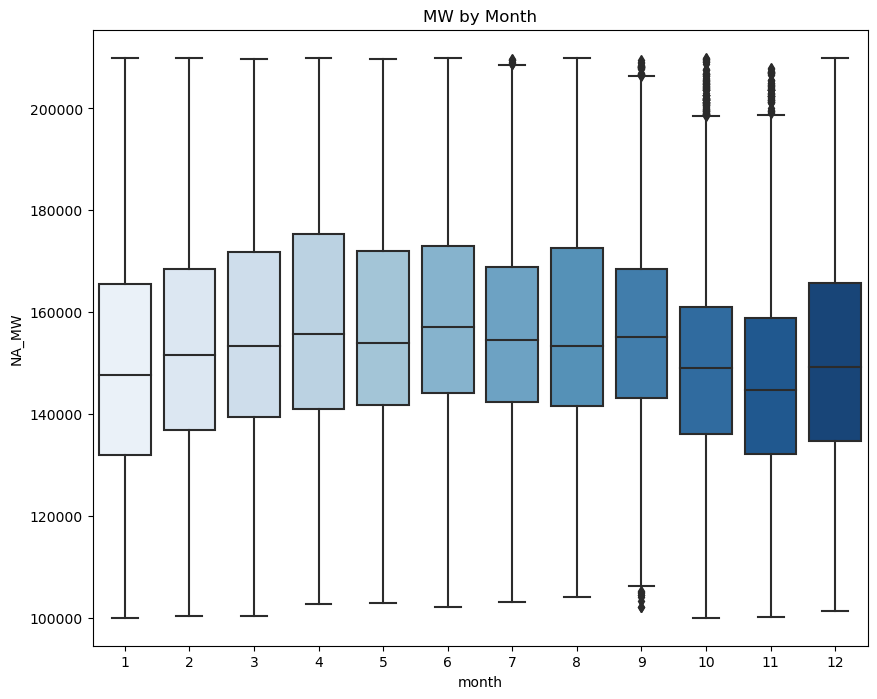

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='month', y='NA_MW', palette='Blues')
ax.set_title('MW by Month')
plt.show()

In [ ]:
train = create_features(train)
test = create_features(test)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
TARGET = 'NA_MW'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    'learning_rate': [0.01, 0.03, 0.05],
    'n_estimators': [500, 1000, 1500],
    'max_depth': [3, 4, 5],
    'min_child_weight': [1, 5, 10],
    'colsample_bytree': [0.4, 0.6],
    'subsample': [0.4, 0.6],
    'gamma': [0, 1, 5]
}
grid = GridSearchCV(
    estimator=XGBRegressor(reg_alpha=15, reg_lambda=30, random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    n_jobs=-1
)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits
Best Parameters: {'colsample_bytree': 0.4, 'gamma': 0, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 1500, 'subsample': 0.6}


In [ ]:
from xgboost import XGBRegressor

# Optimized model with the best parameters
optimized_reg = XGBRegressor(
    n_estimators=2000,           # Keep a large number of trees
    colsample_bytree=0.4,        # Best value from grid search
    learning_rate=0.03,          # Lower learning rate for gradual optimization
    max_depth=3,                 # Slightly deeper trees
    min_child_weight=10,         # Prevent overfitting by requiring more samples per leaf
    subsample=0.6,               # Introduce randomness with 40% sampling
    reg_alpha=15,                # Retain strong L1 regularization
    reg_lambda=30,               # Retain strong L2 regularization
    early_stopping_rounds=50,    # Stop if no improvement in 30 rounds
    objective='reg:squarederror',
    random_state=42,              # Reproducibility
    gamma= 0
)

# Train the optimized model
optimized_reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:20629.59793	validation_1-rmse:30798.25921
[100]	validation_0-rmse:14252.90453	validation_1-rmse:19348.70711
[200]	validation_0-rmse:12469.96742	validation_1-rmse:15118.72350
[300]	validation_0-rmse:11881.57036	validation_1-rmse:13821.20051
[400]	validation_0-rmse:11582.66623	validation_1-rmse:13283.59912
[500]	validation_0-rmse:11351.43306	validation_1-rmse:12957.21187
[600]	validation_0-rmse:11188.03836	validation_1-rmse:12825.46676
[700]	validation_0-rmse:11031.59185	validation_1-rmse:12818.60553
[717]	validation_0-rmse:11001.87449	validation_1-rmse:12807.06806


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.4, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=10, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=2000, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

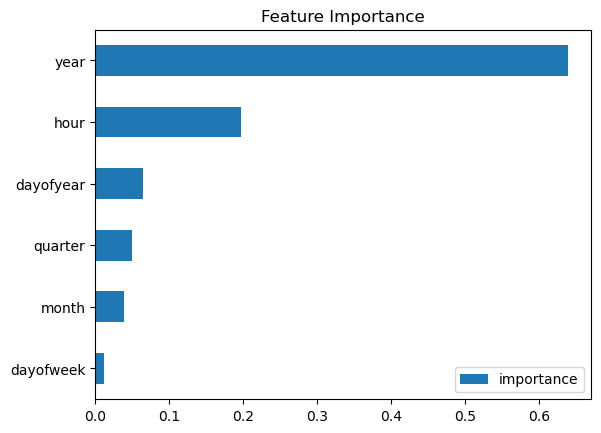

In [ ]:
fi = pd.DataFrame(data=optimized_reg.feature_importances_,
             index=optimized_reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

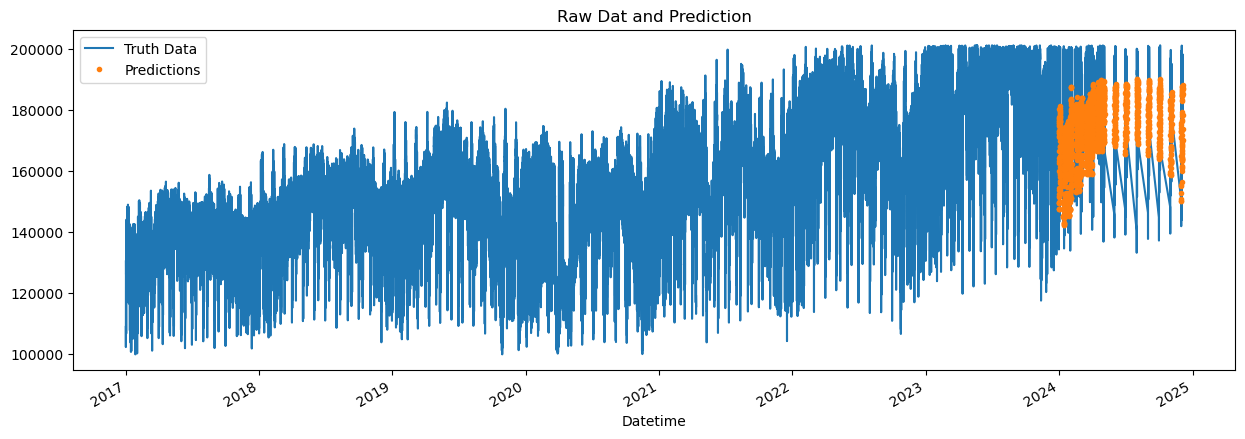

In [ ]:
test['prediction'] = optimized_reg.predict(X_test)
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)
ax = df[['NA_MW']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Dat and Prediction')
plt.show()

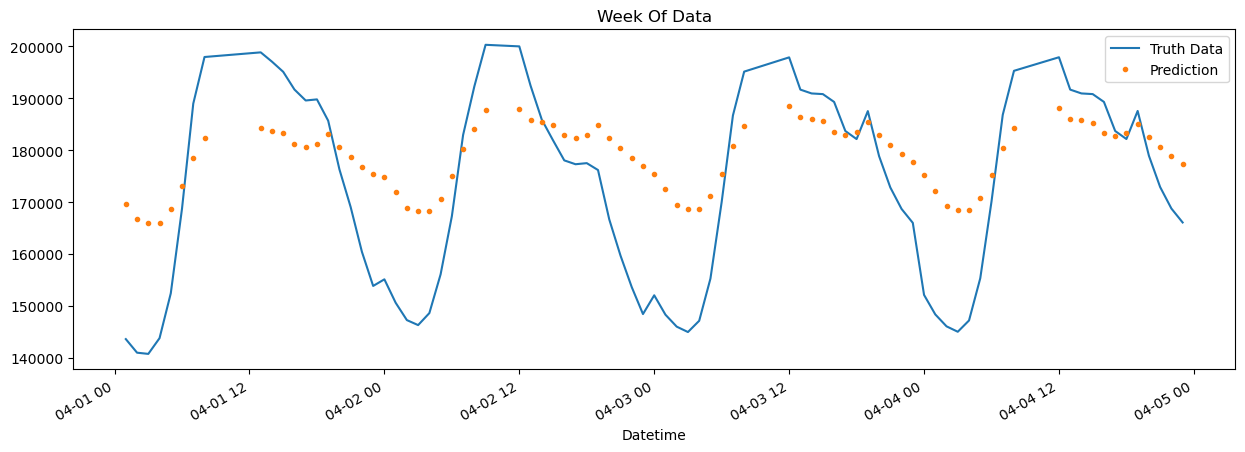

In [ ]:
ax = df.loc[(df.index > '04-01-2024') & (df.index < '04-08-2024')]['NA_MW'] \
    .plot(figsize=(15, 5), title='Week Of Data')
df.loc[(df.index > '04-01-2024') & (df.index < '04-08-2024')]['prediction'] \
    .plot(style='.')
plt.legend(['Truth Data','Prediction'])
plt.show()

In [ ]:
score = np.sqrt(mean_squared_error(test['NA_MW'], test['prediction']))
print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 12318.58


In [ ]:
test['error'] = np.abs(test[TARGET] - test['prediction'])
test['date'] = test.index.date
test.groupby(['date'])['error'].mean().sort_values(ascending=False).head(10)

date
2024-03-29    20555.840742
2024-03-28    19639.919917
2024-03-30    19135.232461
2024-03-31    16918.984036
2024-04-28    16675.938458
2024-04-29    16514.847148
2024-08-01    16431.338214
2024-05-02    15407.026250
2024-06-01    15382.395031
2024-05-01    15344.925757
Name: error, dtype: float64

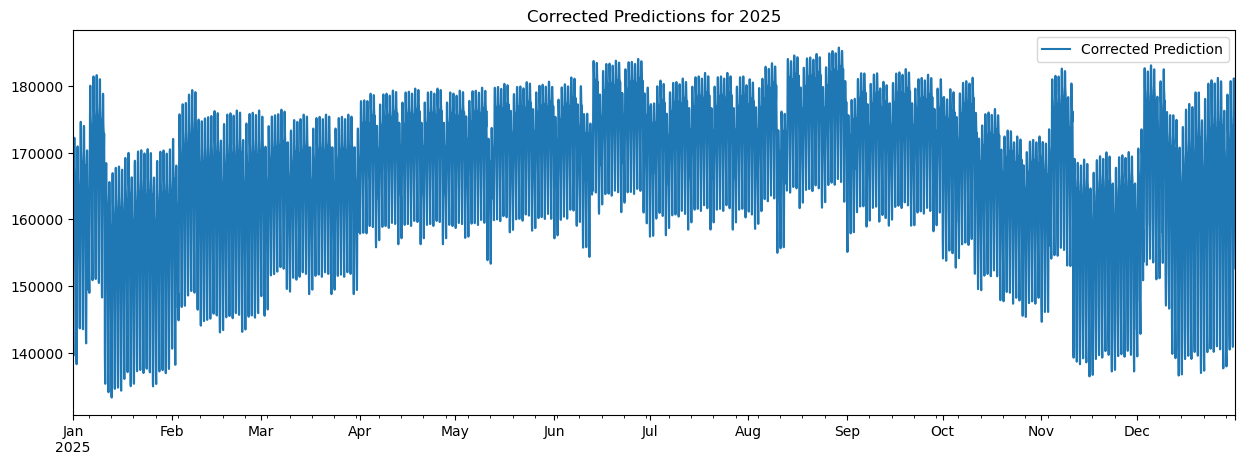

                     hour  dayofweek  quarter  month  year  dayofyear  \
2025-01-01 00:00:00     0          2        1      1  2025          1   
2025-01-01 01:00:00     1          2        1      1  2025          1   
2025-01-01 02:00:00     2          2        1      1  2025          1   
2025-01-01 03:00:00     3          2        1      1  2025          1   
2025-01-01 04:00:00     4          2        1      1  2025          1   

                       prediction  corrected_prediction  
2025-01-01 00:00:00  154278.09375         144125.703125  
2025-01-01 01:00:00  152088.21875         141935.828125  
2025-01-01 02:00:00  149865.15625         139712.765625  
2025-01-01 03:00:00  149719.68750         139567.296875  
2025-01-01 04:00:00  149727.18750         139574.796875  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Assuming `optimized_reg` is your trained XGBoost model and `test` has the actual test data
# Existing features used in the model
FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
TARGET = 'NA_MW'

# Step 1: Create a Datetime Index for the future (2025–2026)
future_dates = pd.date_range(start='2025-01-01', end='2026-12-31', freq='H')
future_df = pd.DataFrame(index=future_dates)

# Step 2: Generate features for the future data
future_df['hour'] = future_df.index.hour
future_df['dayofweek'] = future_df.index.dayofweek
future_df['quarter'] = future_df.index.quarter
future_df['month'] = future_df.index.month
future_df['year'] = future_df.index.year
future_df['dayofyear'] = future_df.index.dayofyear

# Step 3: Extract the feature matrix for predictions
X_future = future_df[FEATURES]

# Step 4: Predict using the trained model
future_df['prediction'] = optimized_reg.predict(X_future)

# Step 5: Calculate mean error correction based on test data (optional)
test['error'] = np.abs(test[TARGET] - test['prediction'])  # Compute errors if not already done
mean_error_correction = test['error'].mean()  # Mean absolute error from test set

# Apply error correction to future predictions
future_df['corrected_prediction'] = future_df['prediction'] - mean_error_correction

# Step 6: Visualize predictions for 2025
ax = future_df['2025-01':'2025-12']['corrected_prediction'] \
    .plot(figsize=(15, 5), title='Corrected Predictions for 2025')
plt.legend(['Corrected Prediction'])
plt.show()

# (Optional) Display the first few rows of the future_df for validation
print(future_df.head())